In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, pearsonr
import warnings
warnings.filterwarnings("ignore")
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:

df = pd.read_csv("C:\\Users\\bhagatsing\\Downloads\\AICTE_Project\\seasonal_agriculture_performance_dataset (3).csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 4000
Number of Columns: 28

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing)

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [2]:
duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

NameError: name 'df' is not defined

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [ ]:
print("Seasons:")
print(df["Season"].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [ ]:
print("Crops:")
print(df["Crop"].value_counts())

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [ ]:
print("States:")
print(df["State"].nunique())

States:
8


In [ ]:
print("Irrigation Methods:")
print(df["Irrigation_Method"].value_counts())

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns
print("Numeric columns:")
print(list(numeric_columns))

Numeric columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [4]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 120


In [5]:
important_numeric = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]
for col in important_numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {count} potential outliers")

Rainfall_mm: 0 potential outliers
Avg_Temperature_C: 2 potential outliers
Soil_Moisture_pct: 3 potential outliers
Yield_Tonnes_Ha: 302 potential outliers
Production_Tonnes: 333 potential outliers
Market_Price_INR_Tonne: 0 potential outliers
Total_Cost_INR: 0 potential outliers
Revenue_INR: 240 potential outliers
Profit_INR: 404 potential outliers
Water_Used_m3: 276 potential outliers
Water_Efficiency_t_per_1000m3: 322 potential outliers
Disease_Pest_Risk_pct: 10 potential outliers


In [6]:
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    0
)
df["Production_per_Hectare"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Production_Tonnes"] / df["Farm_Area_Hectares"],
    0
)
df["Cost_per_Tonne"] = np.where(
    df["Production_Tonnes"] != 0,
    df["Total_Cost_INR"] / df["Production_Tonnes"],
    0
)
df["Revenue_per_Hectare"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Revenue_INR"] / df["Farm_Area_Hectares"],
    0
)
print(df.head())

   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  \
0       486.40              24.30         69.10                5.80     7.14   
1       855.40              25.70         78.40                5.10     5.20   
2       455.60              23.90         56.40               10.30     5.82   
3       753.20              29.70         65.20                6.30     5.98   
4       101.60              34.10         55.20                6.50     6.90   

   Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potass

In [7]:
season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_summary

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Risk
Season,,,,,,,,,
Kharif,1779,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


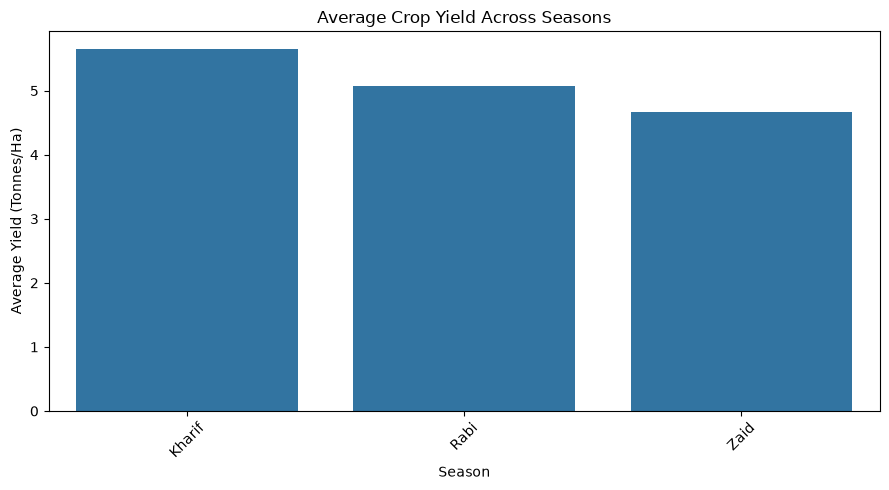

In [8]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

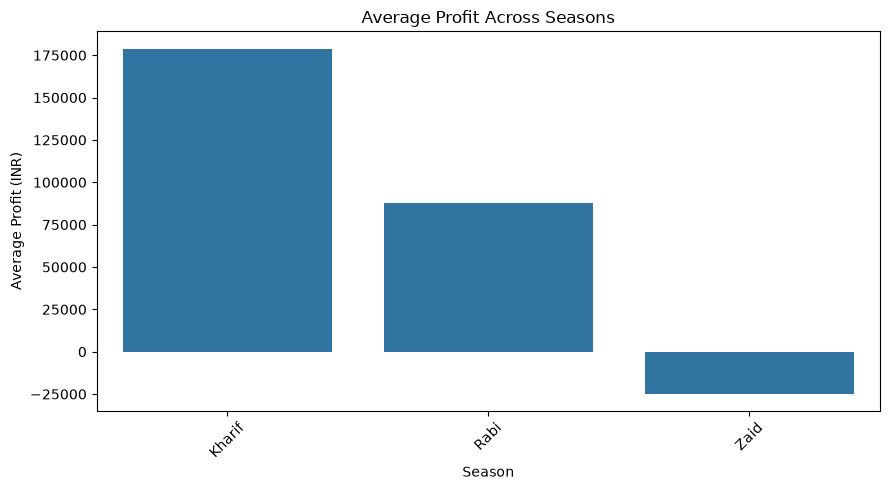

In [32]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

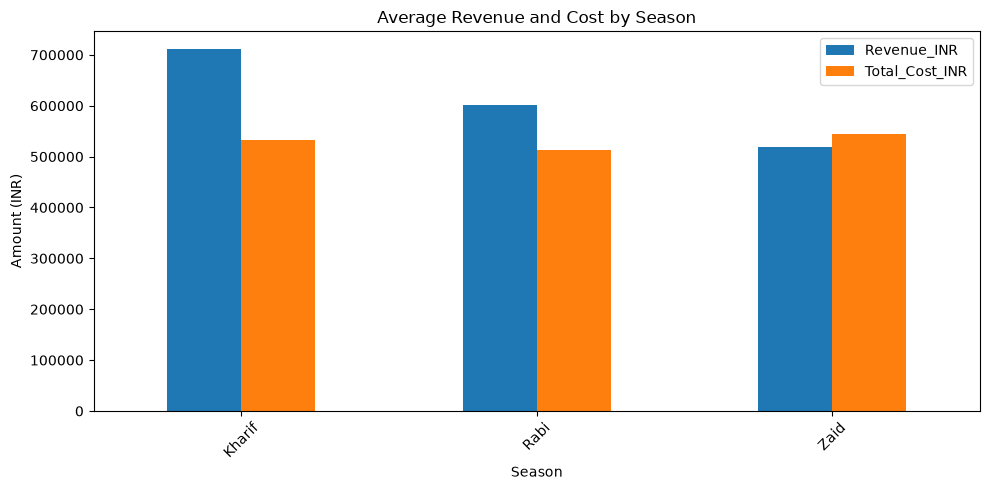

In [33]:
revenue_cost = df.groupby("Season")[[
    "Revenue_INR",
    "Total_Cost_INR"
]].mean()
revenue_cost.plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Average Revenue and Cost by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

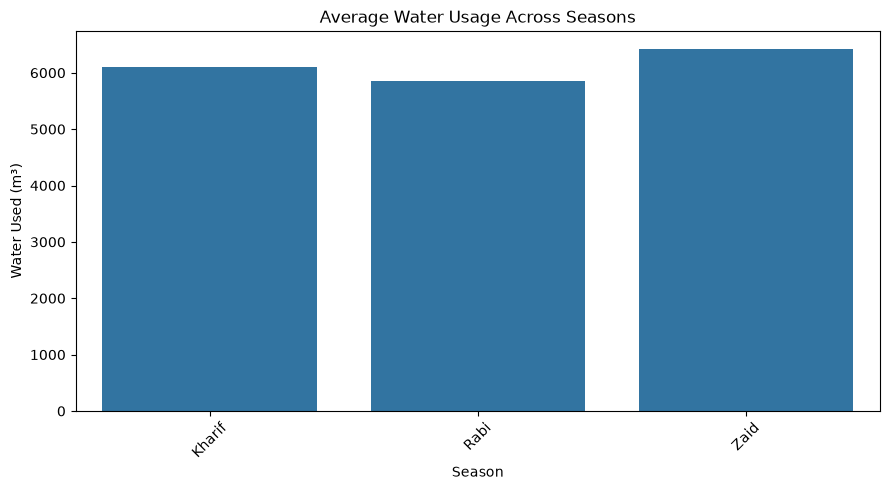

In [34]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator="mean",
    errorbar=None
)
plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

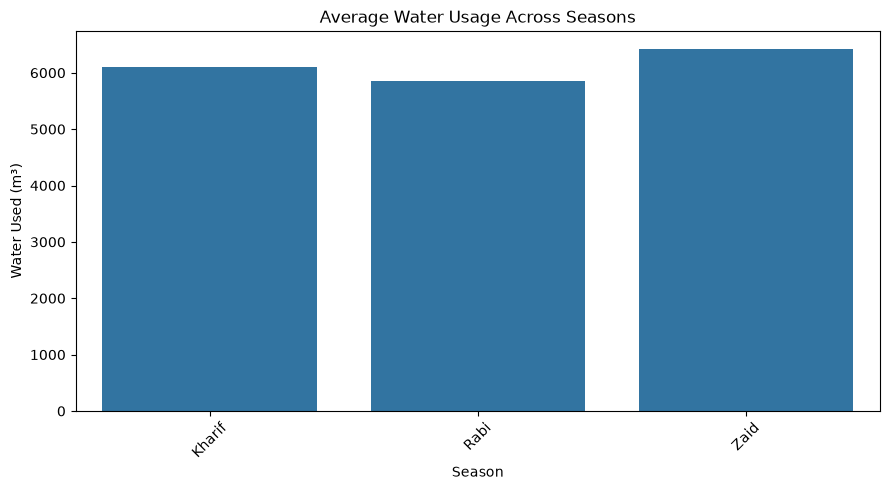

In [35]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator="mean",
    errorbar=None
)
plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

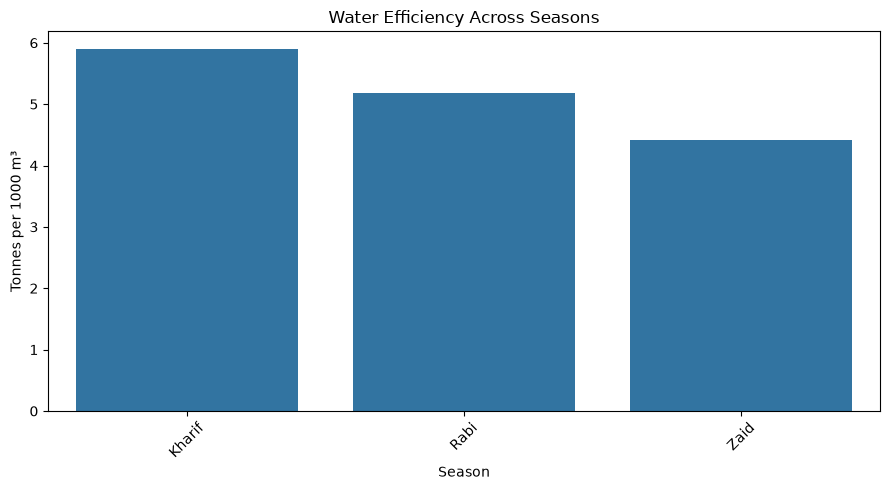

In [36]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None
)
plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

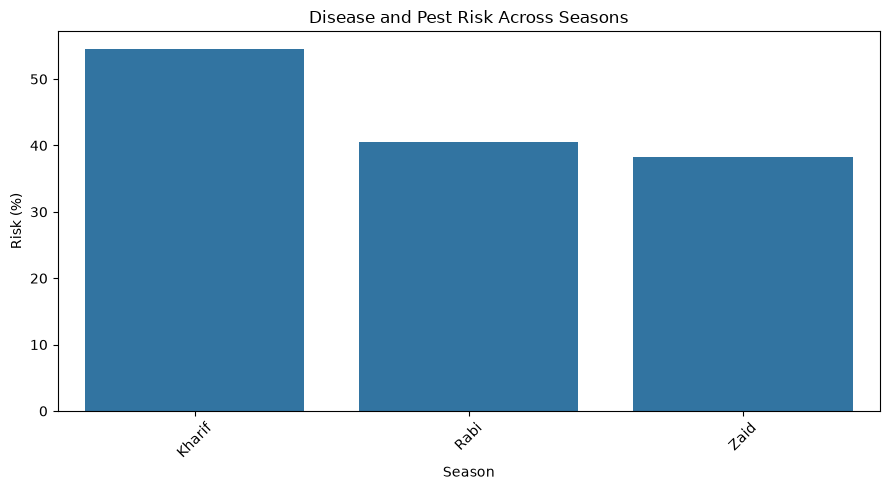

In [37]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct",
    estimator="mean",
    errorbar=None
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
environment = df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]].mean()

environment.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20
Rabi,436.00,23.49,57.89,7.59,24.05
Zaid,299.42,31.04,52.01,8.18,19.17


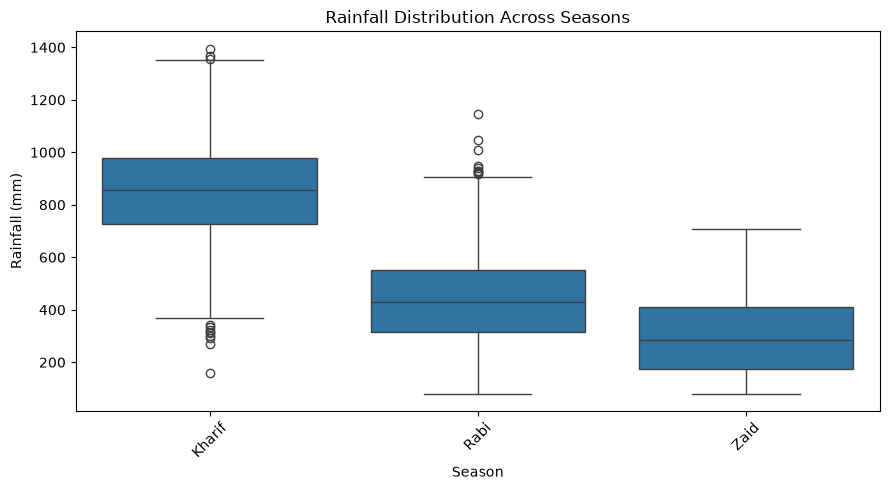

In [39]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Rainfall Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
crop_season = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


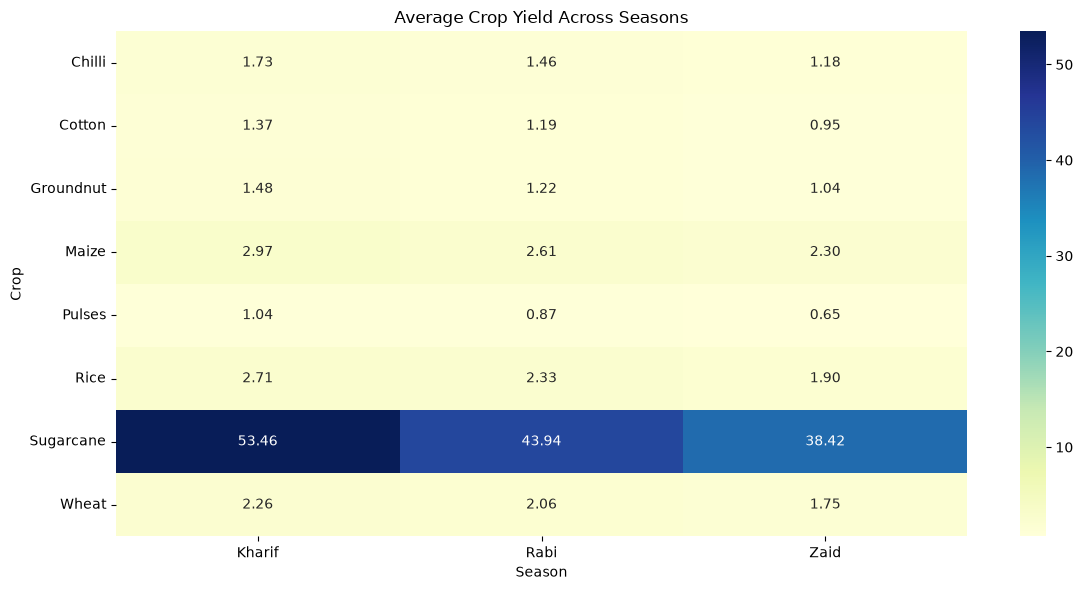

In [41]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [42]:
best_crop = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
)
best_crop = best_crop.loc[
    best_crop.groupby("Season")["Yield_Tonnes_Ha"].idxmax()
]

best_crop.sort_values("Season")

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.46
14,Rabi,Sugarcane,43.94
22,Zaid,Sugarcane,38.42


In [43]:
profit_crop = pd.pivot_table(
    df,
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

profit_crop.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


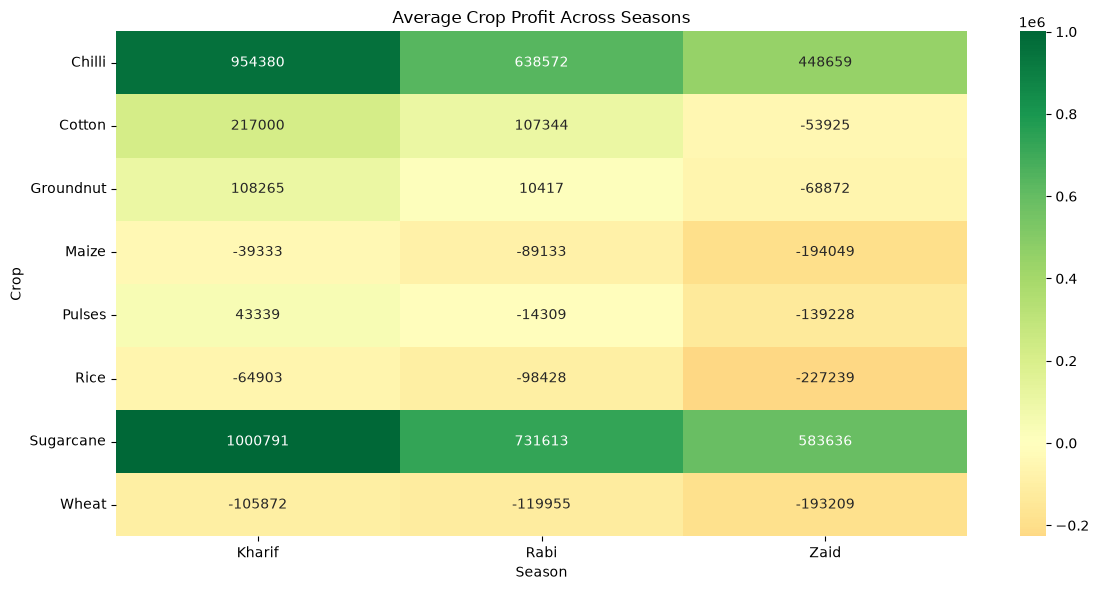

In [44]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    profit_crop,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [45]:
irrigation_summary = df.groupby(
    ["Season", "Irrigation_Method"]
).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Water=("Water_Used_m3", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

irrigation_summary

Avg_Yield  Avg_Water  Avg_Profit  Avg_Efficiency
Season Irrigation_Method                                                  
Kharif Drip                    7.26    5953.37   317222.07            6.80
       Flood                   5.00    8229.27   133373.83            3.64
       Rainfed                 5.72    3687.52   158974.13            8.85
       Sprinkler               4.67    5863.27   116880.49            4.62
Rabi   Drip                    6.21    5911.41   187843.22            6.05
       Flood                   5.10    7766.83    58824.80            3.48
       Rainfed                 3.94    3298.29    45232.48            6.87
       Sprinkler               5.36    6129.09    76502.07            4.64
Zaid   Drip                    5.85    5837.99    21291.84            5.30
       Flood                   4.03    8113.69   -69786.78            2.73
       Rainfed                 3.06    3879.39   -79467.26            5.48
       Sprinkler               6.17    7324.41    57909.40            4.86

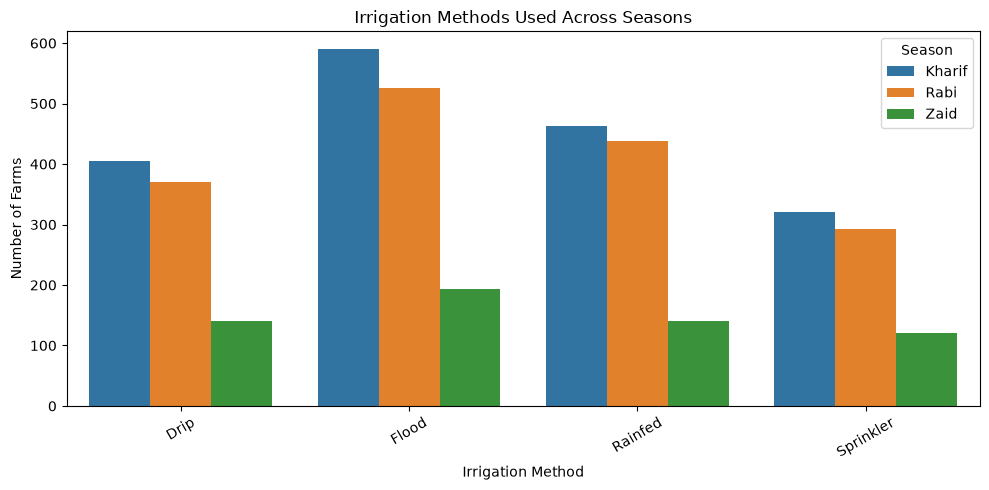

In [47]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Irrigation_Method",
    hue="Season"
)

plt.title("Irrigation Methods Used Across Seasons")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [48]:
resource_summary = df.groupby("Season")[[
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]].mean()

resource_summary.round(2)

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08
Rabi,120.40,57.31,103.93,185.41,5.02
Zaid,120.53,58.13,105.42,184.64,5.17


In [49]:
soil_summary = df.groupby("Season")[[
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha"
]].mean()

soil_summary.round(2)

,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,
Kharif,6.73,31.20,120.02,58.10,105.30
Rabi,6.67,24.05,120.40,57.31,103.93
Zaid,6.69,19.17,120.53,58.13,105.42


In [50]:
state_season = df.groupby(
    ["State", "Season"]
).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Water=("Water_Used_m3", "mean")
).round(2)

state_season.head(20)

Avg_Yield  Avg_Profit  Avg_Rainfall  Avg_Water
State          Season                                                
Andhra Pradesh Kharif       5.69   169315.52        858.23    6598.72
               Rabi         3.49    26315.71        440.14    4872.34
               Zaid         4.48   -84084.87        301.84    7379.21
Gujarat        Kharif       6.34   217051.33        844.78    6227.48
               Rabi         5.52    82846.20        428.95    6018.77
               Zaid         4.10  -106929.61        285.85    6231.52
Karnataka      Kharif       6.52   201226.21        841.76    6980.67
               Rabi         4.61    70952.61        433.80    5709.81
               Zaid         6.62    23310.91        278.87    6776.00
Madhya Pradesh Kharif       6.00   134242.40        864.29    5391.38
               Rabi         3.80    61576.26        428.14    5894.84
               Zaid         5.54      209.70        312.91    5879.19
Maharashtra    Kharif       5.45   168801.05        843.93    5887.46
               Rabi         5.50   159581.50        451.78    6090.03
               Zaid         2.29   -40597.60        301.76    5847.43
Punjab         Kharif       4.10   133779.10        836.47    5817.56
               Rabi         8.61   169294.52        431.68    7415.02
               Zaid         5.91    62109.69        294.67    6662.70
Tamil Nadu     Kharif       5.52   211303.96        846.35    6117.74
               Rabi         4.56    70456.86        444.31    5188.76

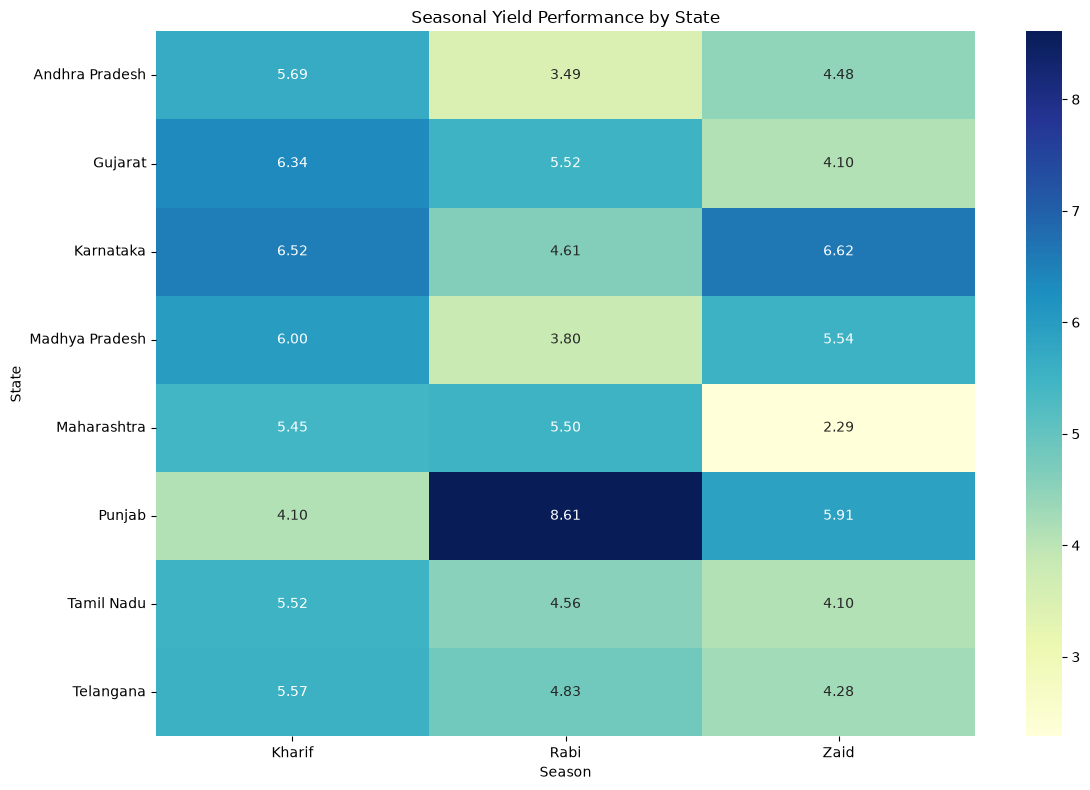

In [51]:
state_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    state_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Seasonal Yield Performance by State")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

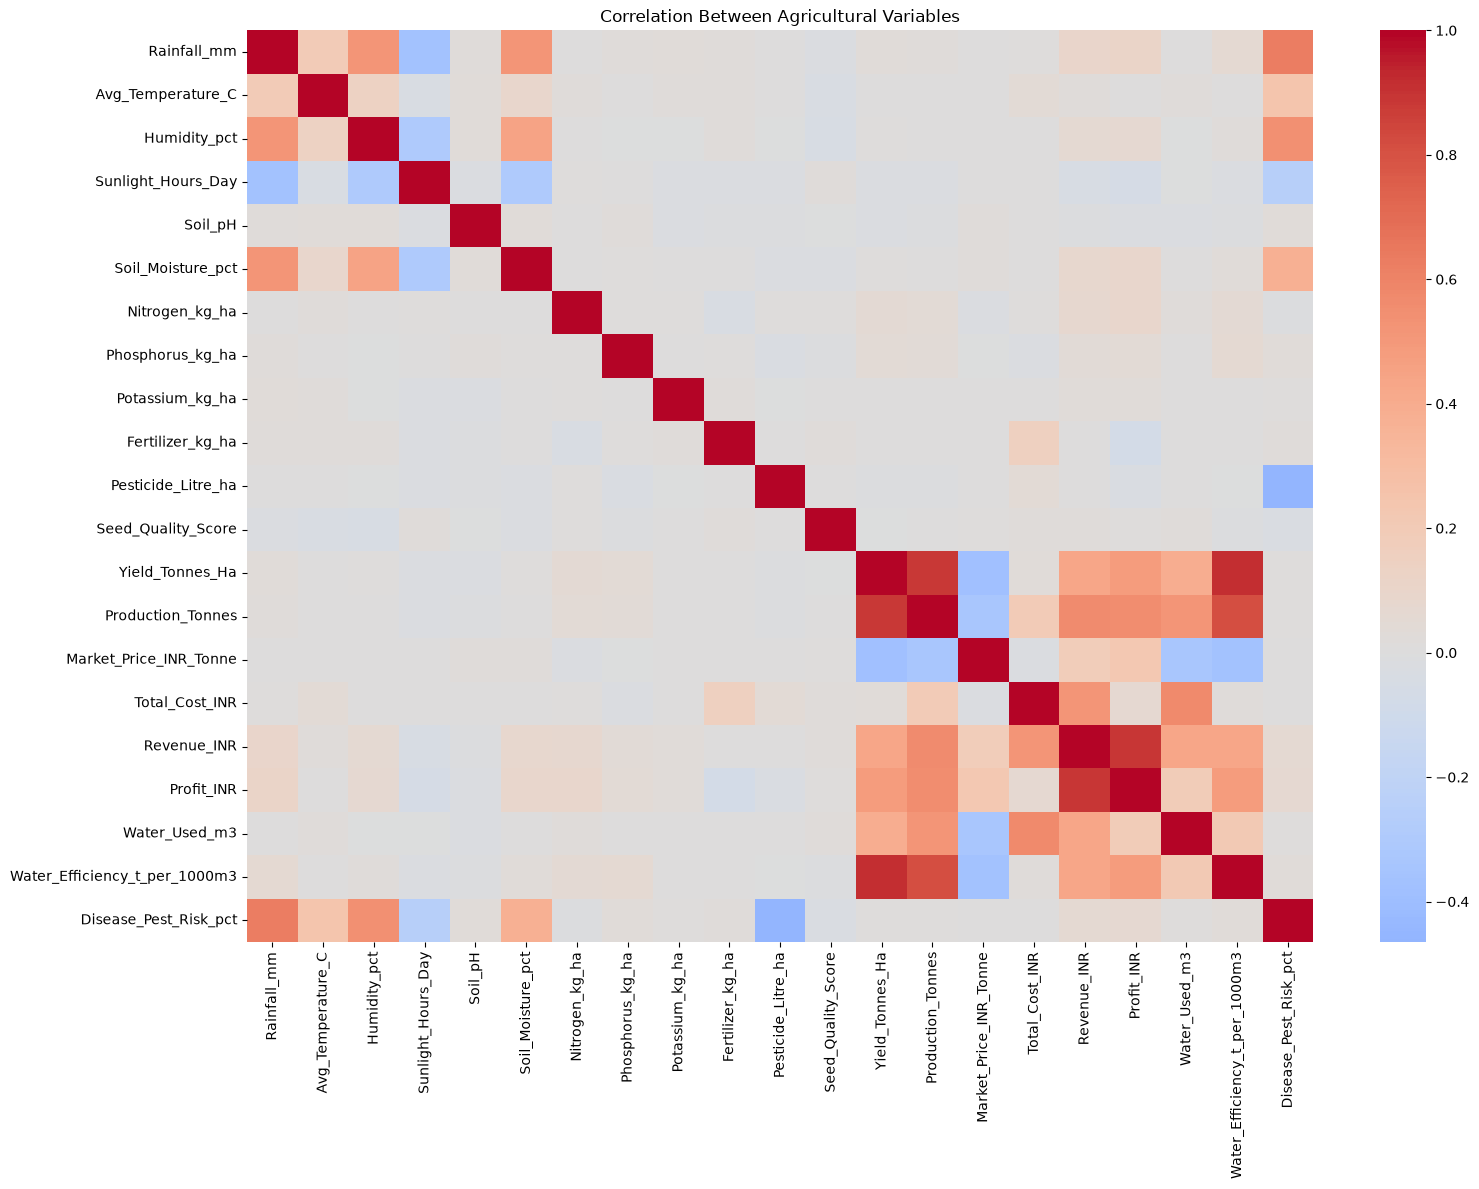

In [52]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Agricultural Variables")
plt.tight_layout()
plt.show()

In [53]:
yield_corr = corr["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

yield_corr

Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.92
Production_Tonnes                0.89
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64

In [54]:
profit_corr = corr["Profit_INR"].sort_values(
    ascending=False
)

profit_corr

Profit_INR                       1.00
Revenue_INR                      0.89
Production_Tonnes                0.55
Yield_Tonnes_Ha                  0.49
Water_Efficiency_t_per_1000m3    0.49
Market_Price_INR_Tonne           0.23
Water_Used_m3                    0.19
Rainfall_mm                      0.11
Soil_Moisture_pct                0.09
Nitrogen_kg_ha                   0.09
Total_Cost_INR                   0.07
Disease_Pest_Risk_pct            0.07
Humidity_pct                     0.06
Phosphorus_kg_ha                 0.05
Potassium_kg_ha                  0.03
Seed_Quality_Score               0.01
Avg_Temperature_C                0.01
Soil_pH                         -0.01
Pesticide_Litre_ha              -0.03
Sunlight_Hours_Day              -0.05
Fertilizer_kg_ha                -0.07
Name: Profit_INR, dtype: float64

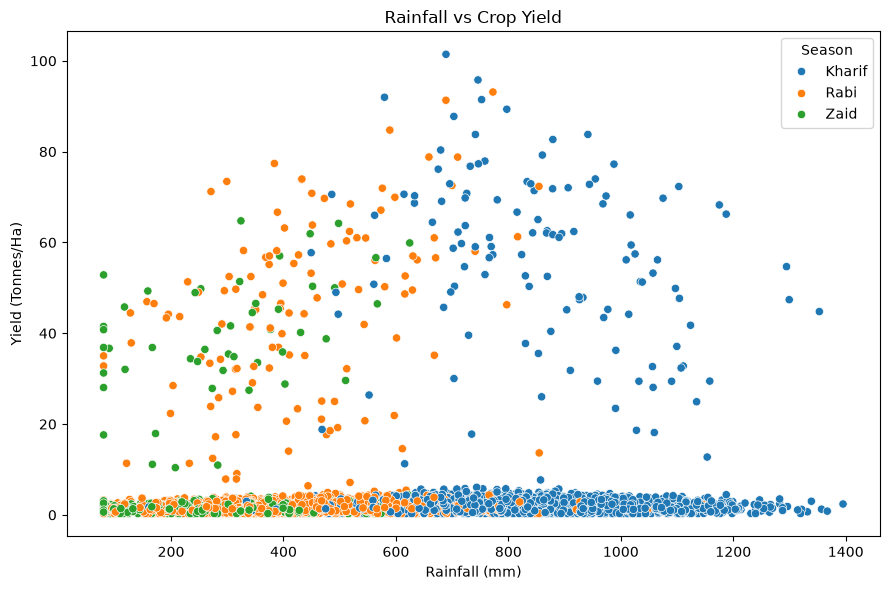

In [55]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

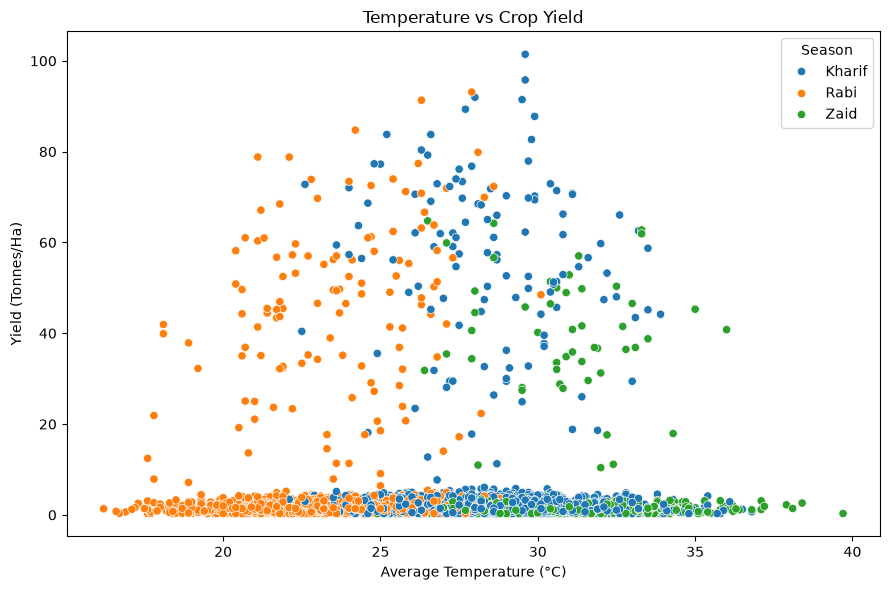

In [56]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

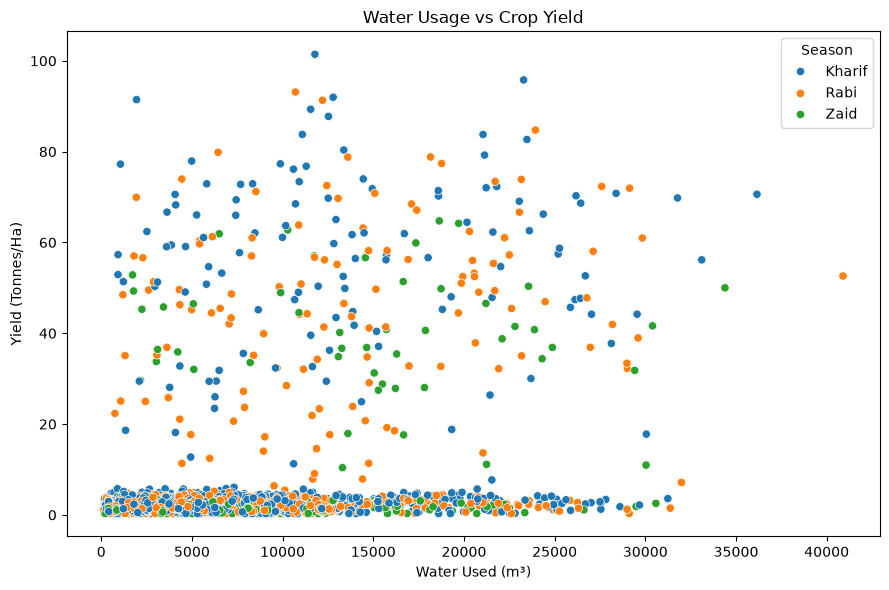

In [57]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [58]:
season_groups = [
    group["Yield_Tonnes_Ha"].values
    for _, group in df.groupby("Season")
]

anova_result = f_oneway(*season_groups)

print("ANOVA F-statistic:", round(anova_result.statistic, 4))
print("ANOVA p-value:", round(anova_result.pvalue, 6))

ANOVA F-statistic: nan
ANOVA p-value: nan


In [59]:
profit_groups = [
    group["Profit_INR"].values
    for _, group in df.groupby("Season")
]

profit_anova = f_oneway(*profit_groups)

print("F-statistic:", round(profit_anova.statistic, 4))
print("p-value:", round(profit_anova.pvalue, 6))

F-statistic: 34.2918
p-value: 0.0


In [60]:
if profit_anova.pvalue < 0.05:
    print("Seasonal differences in profit are statistically significant.")
else:
    print("No statistically significant seasonal difference in profit was detected.")

Seasonal differences in profit are statistically significant.


In [61]:
r, p = pearsonr(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"]
)

print("Correlation coefficient:", round(r, 4))
print("p-value:", round(p, 6))

Correlation coefficient: nan
p-value: nan


In [62]:
if p < 0.05:
    print("The relationship between rainfall and yield is statistically significant.")
else:
    print("The relationship between rainfall and yield is not statistically significant.")

The relationship between rainfall and yield is not statistically significant.


In [63]:
season_performance = df.groupby("Season").agg(
    Yield=("Yield_Tonnes_Ha", "mean"),
    Profit=("Profit_INR", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Risk=("Disease_Pest_Risk_pct", "mean")
)

best_yield_season = season_performance["Yield"].idxmax()
worst_yield_season = season_performance["Yield"].idxmin()

best_profit_season = season_performance["Profit"].idxmax()
worst_profit_season = season_performance["Profit"].idxmin()

print("Highest average yield:", best_yield_season)
print("Lowest average yield:", worst_yield_season)

print("Highest average profit:", best_profit_season)
print("Lowest average profit:", worst_profit_season)

Highest average yield: Kharif
Lowest average yield: Zaid
Highest average profit: Kharif
Lowest average profit: Zaid


In [64]:
yield_Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
yield_Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

yield_IQR = yield_Q3 - yield_Q1

upper_yield = yield_Q3 + 1.5 * yield_IQR
lower_yield = yield_Q1 - 1.5 * yield_IQR

unusual_yield = df[
    (df["Yield_Tonnes_Ha"] > upper_yield) |
    (df["Yield_Tonnes_Ha"] < lower_yield)
]

print("Unusual yield records:", len(unusual_yield))

unusual_yield[
    [
        "Farm_ID",
        "State",
        "District",
        "Crop",
        "Season",
        "Yield_Tonnes_Ha",
        "Rainfall_mm",
        "Water_Used_m3",
        "Profit_INR"
    ]
].head(20)

Unusual yield records: 302


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Rainfall_mm,Water_Used_m3,Profit_INR
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,36.69,90.00,13263,556688
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,62.58,869.00,23608,1675730
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,33.55,353.90,8213,691166
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,49.52,629.30,2611,279221
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,70.23,973.70,18596,2427692
113,SF10114,Tamil Nadu,Rajkot,Sugarcane,Rabi,58.06,740.80,27123,2324331
132,SF10133,Telangana,Warangal,Sugarcane,Kharif,29.47,1158.20,6337,89113
154,SF10155,Telangana,Ludhiana,Sugarcane,Kharif,47.88,932.60,21550,798280
155,SF10156,Madhya Pradesh,Guntur,Sugarcane,Kharif,62.09,867.90,8473,573019
164,SF10165,Telangana,Guntur,Sugarcane,Rabi,36.91,391.20,3618,297233


In [65]:
risk_summary = df.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean().sort_values(ascending=False)

risk_summary

Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64

In [66]:
print(
    "Highest average disease/pest risk:",
    risk_summary.idxmax()
)

Highest average disease/pest risk: Kharif


In [70]:
season_score["Seasonal_Performance_Score"] = (
    season_score["Yield_Score"] * 0.30 +
    season_score["Profit_Score"] * 0.30 +
    season_score["Water_Score"] * 0.20 +
    season_score["Risk_Score"] * 0.20
) * 100

season_score = season_score.sort_values(
    "Seasonal_Performance_Score",
    ascending=False
)

season_score.round(2)

,Yield,Profit,Water_Efficiency,Risk,Yield_Score,Profit_Score,Water_Score,Risk_Score,Seasonal_Performance_Score
Season,,,,,,,,,
Kharif,5.64,178914.65,5.89,54.47,1.00,1.00,1.00,0.00,80.00
Rabi,5.08,87689.47,5.19,40.48,0.42,0.55,0.52,0.86,56.95
Zaid,4.67,-24804.82,4.41,38.22,0.00,0.00,0.00,1.00,20.00


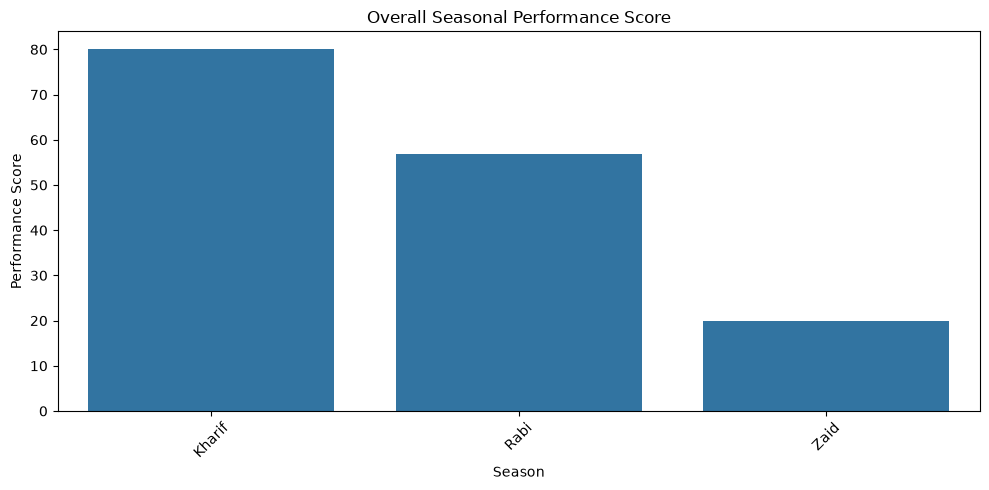

In [71]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=season_score.index,
    y=season_score["Seasonal_Performance_Score"]
)

plt.title("Overall Seasonal Performance Score")
plt.xlabel("Season")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
crop_season_performance = df.groupby(
    ["Crop", "Season"]
).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    )
).reset_index()

crop_season_performance = crop_season_performance.sort_values(
    "Avg_Profit",
    ascending=False
)

crop_season_performance.head(10)

,Crop,Season,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
18,Sugarcane,Kharif,53.46,1000790.81,36.00
0,Chilli,Kharif,1.73,954380.42,3.26
19,Sugarcane,Rabi,43.94,731612.86,27.92
1,Chilli,Rabi,1.46,638572.50,2.89
20,Sugarcane,Zaid,38.42,583635.80,23.39
2,Chilli,Zaid,1.18,448659.09,2.20
3,Cotton,Kharif,1.37,216999.55,2.13
6,Groundnut,Kharif,1.48,108265.44,3.58
4,Cotton,Rabi,1.19,107343.59,1.94
12,Pulses,Kharif,1.04,43338.90,3.35


In [73]:
final_ranking = season_score[
    [
        "Yield",
        "Profit",
        "Water_Efficiency",
        "Risk",
        "Seasonal_Performance_Score"
    ]
].copy()

final_ranking

,Yield,Profit,Water_Efficiency,Risk,Seasonal_Performance_Score
Season,,,,,
Kharif,5.64,178914.65,5.89,54.47,80.00
Rabi,5.08,87689.47,5.19,40.48,56.95
Zaid,4.67,-24804.82,4.41,38.22,20.00


In [74]:
best_yield = season_summary["Avg_Yield"].idxmax()
best_profit = season_summary["Avg_Profit"].idxmax()
best_water = season_summary["Avg_Water_Efficiency"].idxmax()
highest_risk = season_summary["Avg_Risk"].idxmax()

print("========== KEY FINDINGS ==========\n")

print(
    f"1. {best_yield} recorded the highest average crop yield."
)

print(
    f"2. {best_profit} recorded the highest average profit."
)

print(
    f"3. {best_water} showed the highest average water efficiency."
)

print(
    f"4. {highest_risk} showed the highest average disease/pest risk."
)

print(
    f"5. The highest overall analytical seasonal performance "
    f"was observed in {season_score.index[0]}."
)

========== KEY FINDINGS ==========

1. Kharif recorded the highest average crop yield.
2. Kharif recorded the highest average profit.
3. Kharif showed the highest average water efficiency.
4. Kharif showed the highest average disease/pest risk.
5. The highest overall analytical seasonal performance was observed in Kharif.


In [76]:


print(
    f"• Consider the seasonal conditions associated with "
    f"higher performance during agricultural planning."
)

print(
    f"• Investigate the environmental and farming factors "
    f"associated with higher yield in {best_yield}."
)

print(
    f"• Review resource usage and water-efficiency practices "
    f"observed during {best_water}."
)

print(
    f"• Additional monitoring may be useful during "
    f"{highest_risk}, where disease/pest risk is comparatively higher."
)

print(
    "• Crop and regional differences should be considered "
    "instead of applying one seasonal strategy to all farms."
)

• Consider the seasonal conditions associated with higher performance during agricultural planning.
• Investigate the environmental and farming factors associated with higher yield in Kharif.
• Review resource usage and water-efficiency practices observed during Kharif.
• Additional monitoring may be useful during Kharif, where disease/pest risk is comparatively higher.
• Crop and regional differences should be considered instead of applying one seasonal strategy to all farms.


In [ ]:
final_report = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    ),
    Avg_Disease_Pest_Risk=(
        "Disease_Pest_Risk_pct",
        "mean"
    )
).round(2)

final_report